In [12]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from skimage.io import imread
from skimage.transform import resize
import numpy as np
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu, sobel
from skimage.transform import resize
from skimage.feature import canny
from skimage import morphology, measure
import numpy as np
import torch
from skimage import measure, morphology

import numpy as np
from skimage import measure


def count_holes(binary_image):
    """
    Counts the number of internal holes in the image.
    
    Image Definition: Foreground=0, Background/Holes=1.
    
    This function counts only the connected regions of '1's that are 
    completely enclosed by the '0' foreground objects (internal holes), 
    excluding the main external background region (which touches the border).
    
    Args:
        binary_image: 2D numpy array, foreground=0, background=1.
    
    Returns:
        The total number of internal holes.
    """
    
    # 1. Label all connected components of the background (the '1's).
    # We use 4-connectivity (connectivity=1) for counting holes.
    labeled_bg = measure.label(binary_image.astype(np.uint8), connectivity=1)
    
    # 2. Identify the labels of all regions that touch the image border. 
    # The largest of these is the main external background, which we exclude.
    border_labels = np.unique(np.concatenate([
        labeled_bg[0, :], labeled_bg[-1, :], labeled_bg[:, 0], labeled_bg[:, -1]
    ]))
    
    # 3. Get the set of all unique labels for background components (excluding 0, the foreground label).
    all_bg_labels = set(np.unique(labeled_bg))
    all_bg_labels.discard(0) 
    
    # 4. Get the set of labels to exclude (those touching the border).
    border_label_set = set(border_labels)
    
    # 5. The hole labels are the difference: all background components minus those touching the border.
    hole_labels = all_bg_labels - border_label_set
    
    return len(hole_labels)


class SkimageDataset(Dataset):
    def __init__(self, root_dir, image_size=(128, 128), transform=None, binary=False):
        self.samples = []
        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.class_names)}
        self.image_size = image_size
        self.transform = transform
        self.binary = binary   # <-- this was missing!

        for cls_name in self.class_names:
            cls_path = os.path.join(root_dir, cls_name)
            if not os.path.isdir(cls_path):
                continue
            for fname in os.listdir(cls_path):
                if fname.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.samples.append((os.path.join(cls_path, fname), self.class_to_idx[cls_name]))

    def __len__(self):
        # Return number of samples
        return len(self.samples)


    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = imread(path)
        img = resize(img, self.image_size, anti_aliasing=True)

        if self.binary:
            # 1. Convert to grayscale
            img_gray = rgb2gray(img)
            thresh = threshold_otsu(img_gray)
            img_binary = (img_gray > thresh).astype(np.float32)
            img_binary = 1.0 - img_binary
            holes = count_holes(img_binary)     
            features = holes
            labeled_foreground = measure.label(img_binary)
            # for region in measure.regionprops(labeled_foreground):
            #     features.append([
            #         # region.area,
            #         # region.perimeter,
            #         # region.eccentricity,
            #     ])

            # 4. Convert to tensor
            img = torch.tensor(img_binary, dtype=torch.bool).unsqueeze(0)
        else:
            if self.transform:
                img = self.transform(img)
            img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)

        label = torch.tensor(label, dtype=torch.long)
        return (img, features), label

In [13]:
import matplotlib.pyplot as plt

def show_batch_images_matplotlib(batch_imgs, batch_labels):
    """
    batch_imgs: Tensor of shape (B, C, H, W)
    batch_labels: Tensor of shape (B,)
    """
    batch_size = batch_imgs.shape[0]
    plt.figure(figsize=(15, 5))
    
    for i in range(batch_size):
        img = batch_imgs[i]
        label = batch_labels[i]
        
        if img.shape[0] == 1:  # grayscale
            img_to_show = img.squeeze(0).numpy()
            cmap = 'gray'
        else:  # RGB
            img_to_show = img.permute(1, 2, 0).numpy()
            cmap = None
        
        plt.subplot(1, batch_size, i+1)
        plt.imshow(img_to_show, cmap=cmap)
        plt.title(f"Label: {label.item()}")
        plt.axis('off')
        print()
    
    plt.show()



In [14]:
dataset = SkimageDataset("./splited_dataset/test", image_size=(128, 128), binary=True)

In [15]:

# dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# # Usage with your DataLoader
# for batch_imgs, batch_labels in dataloader:
#     print(batch_imgs.shape)   # (16, 3, 128, 128)
#     print(batch_labels.shape) # (16,)
#     show_batch_images_matplotlib(batch_imgs, batch_labels)
#     break

0
13231


/tmp/ipykernel_313588/1437849352.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  count = Counter(np.array(features[0], dtype=np.bool).flatten())


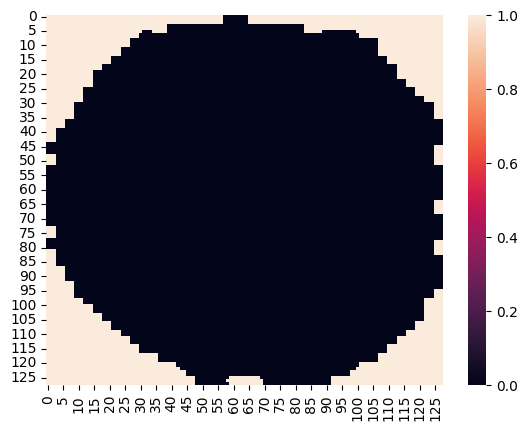

In [16]:
import time
import seaborn as sns
from collections import Counter
for features, labels in dataset[4132]: 
    sns.heatmap(features[0].reshape(128,128))
    # print(features[1])
    print(labels)
    count = Counter(np.array(features[0], dtype=np.bool).flatten())
    print(count[0])
    break

In [17]:
import numpy as np
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from collections import defaultdict
from collections import Counter

# Prepare the data
X = []
y = []

for features, label in dataset:
    # f1 = np.concat([features[0].flatten(), features[1].flatten()])
    count = Counter(features[0].numpy().flatten())
    X.append([count[0], count[1],features[1]])
    y.append(label.item())



In [18]:
len(X), len(y)

(4133, 4133)

In [25]:
import pandas as pd 
df = pd.DataFrame(X, columns=['1s','0s','holes'])
# df['Class'] = y

In [26]:
df

,1s,0s,holes
0,11673,4711,4
1,12368,4016,0
2,12504,3880,3
3,11557,4827,2
4,11439,4945,1
...,...,...,...
4128,11177,5207,0
4129,12672,3712,0
4130,12760,3624,0
4131,11748,4636,0


In [27]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
mn = MinMaxScaler()
std = StandardScaler()
# dfstd = mn.fit_transform(df)
dfstd = std.fit_transform(df)

In [28]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(dfstd,y, test_size=0.2)

In [31]:
# 2️⃣ List of classifiers
classifiers = [
    ("SVM", SVC()),
    ("Random Forest", RandomForestClassifier()),
    ("Logistic Regression", LogisticRegression(max_iter=1000))
]

# 3️⃣ Run each classifier and save results
results = []

for name, clf in classifiers:
    scores = cross_val_score(clf, xtrain, ytrain, cv=5)  # 5-fold CV
    mean_acc = scores.mean()
    results.append({"Classifier": name, "Mean Accuracy": mean_acc})

In [32]:
import pandas as pd
# 4️⃣ Convert results to DataFrame
df_results = pd.DataFrame(results)
print(df_results)

            Classifier  Mean Accuracy
0                  SVM       0.887783
1        Random Forest       0.824871
2  Logistic Regression       0.886876
